# **NFL Scoring Probability Model**
By Andrew Wolfe

The objective of this project is to estimate the probability of an NFL drive concluding in a score based on play-by-play statistics in the 2021-2023 seasons. I calculated features that utilize both long-term team trends, as well as more recent short-term momentum. After that, I trained a variety of machine learning models and evaluated their predictive performance based on standard industry metrics.

I then evaluated the performance of the models, conducted feature importance, and created a interactive feature for users in the future.

**Import Python Libraries and Merge Datasets**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score,log_loss
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from scipy import sparse
import joblib
from collections import defaultdict, deque
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import plotly.express as px
import matplotlib.pyplot as plt
from ipywidgets import interact_manual, widgets, Output
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import seaborn as sns
from sklearn.inspection import permutation_importance

**Loading and Merging Datasets from the 2021-2023 NFL Seasons**

In [ ]:
play1 = pd.read_csv('play_by_play_2021.csv')
play2 = pd.read_csv('play_by_play_2022.csv')
play3 = pd.read_csv('play_by_play_2023.csv')

df = pd.concat([play1, play2, play3], ignore_index=True)

/tmp/ipython-input-45-2772530807.py:1: DtypeWarning: Columns (179,180,182,183,189,190,193,194,197,198,203,204,205,206,218,219,220,233,234,235,236,237,238,253,254,255,260,262,263,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  play1 = pd.read_csv('play_by_play_2021.csv')
/tmp/ipython-input-45-2772530807.py:2: DtypeWarning: Columns (45,179,180,182,183,187,188,189,190,193,194,197,198,203,204,205,206,213,214,218,219,220,222,224,226,243,244,245,248,249,253,254,255,260,262,263,266,267,268,269,283,284) have mixed types. Specify dtype option on import or set low_memory=False.
  play2 = pd.read_csv('play_by_play_2022.csv')
/tmp/ipython-input-45-2772530807.py:3: DtypeWarning: Columns (45,179,180,182,183,189,190,197,198,203,204,205,206,218,219,220,222,224,226,253,254,255,260,262,263,283,284,332) have mixed types. Specify dtype option on import or set low_memory=False.
  play3 = pd.read_csv('play_by_play_2023.csv')


**EDA and Assessing the Data**

In the next couple lines of code, I will be reviewing the first couple of rows of the dataset, looking at the data types, and evaluating some basic information with the data.

I will also be dealing with NAs and for simplicity, dropping all rows where our target variable 'drive_ended_with_score' was filled with NA.

In [ ]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

count_numerical_features = len(numerical_features)
count_categorical_features = len(categorical_features)
print(f"Number of Numerical Features: {count_numerical_features}")
print(f"Number of Categorical Features: {count_categorical_features}")

Number of Numerical Features: 215
Number of Categorical Features: 157


In [ ]:
df = df.dropna(subset=['drive_ended_with_score'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147324 entries, 1 to 149019
Columns: 372 entries, play_id to pass_oe
dtypes: float64(176), int64(39), object(157)
memory usage: 419.2+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
play_id,147324.0,2.122279e+03,1225.586558,3.800000e+01,1.067000e+03,2.106000e+03,3.151000e+03,5.523000e+03
old_game_id,147324.0,2.022227e+09,854137.859239,2.021091e+09,2.021122e+09,2.022111e+09,2.023101e+09,2.024021e+09
week,147324.0,9.918913e+00,5.605607,1.000000e+00,5.000000e+00,1.000000e+01,1.500000e+01,2.200000e+01
yardline_100,138236.0,4.870939e+01,24.270240,1.000000e+00,3.100000e+01,5.000000e+01,7.000000e+01,9.900000e+01
quarter_seconds_remaining,147323.0,4.084008e+02,280.632807,0.000000e+00,1.460000e+02,3.890000e+02,6.510000e+02,9.000000e+02
...,...,...,...,...,...,...,...,...
xyac_median_yardage,52016.0,3.667602e+00,2.568964,0.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,3.000000e+01
xyac_success,52016.0,7.766255e-01,0.252254,1.724841e-02,5.592482e-01,9.825983e-01,1.000000e+00,1.000000e+00
xyac_fd,52016.0,5.777844e-01,0.355003,8.024425e-03,2.419491e-01,4.785036e-01,9.991331e-01,1.000000e+00
xpass,113772.0,6.282930e-01,0.240076,1.571486e-02,4.572446e-01,5.993312e-01,8.567732e-01,9.975798e-01


In [ ]:
df.nunique()

,0
play_id,4966
game_id,854
old_game_id,854
home_team,32
away_team,32
...,...
xyac_median_yardage,28
xyac_success,30728
xyac_fd,31526
xpass,112350


In [ ]:
nan_counts = df.isna().sum()
print("Missing values in each column:")
print(nan_counts)

Missing values in each column:
play_id                    0
game_id                    0
old_game_id                0
home_team                  0
away_team                  0
                       ...  
xyac_median_yardage    95308
xyac_success           95308
xyac_fd                95308
xpass                  33552
pass_oe                36541
Length: 372, dtype: int64


**Top 10 NFL Teams by Percentage of Drives Ending in a Score (2021–2023)**

In [ ]:
drives = df.groupby(['game_id', 'drive_play_id_started', 'posteam'])['drive_ended_with_score'].first().dropna()
team_score_pct = drives.groupby(drives.index.get_level_values('posteam')).value_counts(normalize=True).unstack().fillna(0).round(4) * 100
team_score_pct = team_score_pct.rename(columns={0.0: 'No Score', 1.0: 'Scoring %'})[['Scoring %']]


print(team_score_pct.sort_values(by='Scoring %', ascending=False).head(10))

drive_ended_with_score  Scoring %
posteam                          
KC                          46.07
DAL                         45.61
BUF                         45.20
PHI                         43.94
SF                          43.32
LA                          42.93
BAL                         41.98
DET                         41.11
CIN                         41.08
GB                          40.86


From the 2021-2023 seasons, the Kansas City Chiefs led the entire NFL in percentage of offensive drives that ended in a score. About 46% of their drives ended in a score during this three year span.

In [ ]:
league_avg_score_pct = drives.mean() * 100
print(f"\nLeague Average Scoring %: {league_avg_score_pct:.2f}%")


League Average Scoring %: 37.99%


Between the 2021 and 2023 NFL seasons, an average of 37.99% of offensive drives resulted in some type of score.

**Distributions of Important Numerical Variables**

It is essential to explore the characteristics of the potentially important features in terms of distribution, correlations, and skewness. Understanding the distribution of each feature and identifying outlier observations will help determine if any of the variables require scaling or transformation before entering the model. The variables selected below (after the correlation matrix) are a subset of the numerical features that highlight game context and team performance. This smaller selection will help reduce dimensionality and improve interpretation, creating better/improved model performance!

Top 15 features most correlated with 'drive_ended_with_score':
['lateral_rushing_yards', 'ydsnet', 'drive_first_downs', 'drive_inside20', 'fumble_recovery_2_yards', 'drive_play_count', 'series_success', 'ep', 'yardline_100', 'opp_fg_prob', 'kick_distance', 'opp_td_prob', 'sp', 'epa', 'qb_epa']


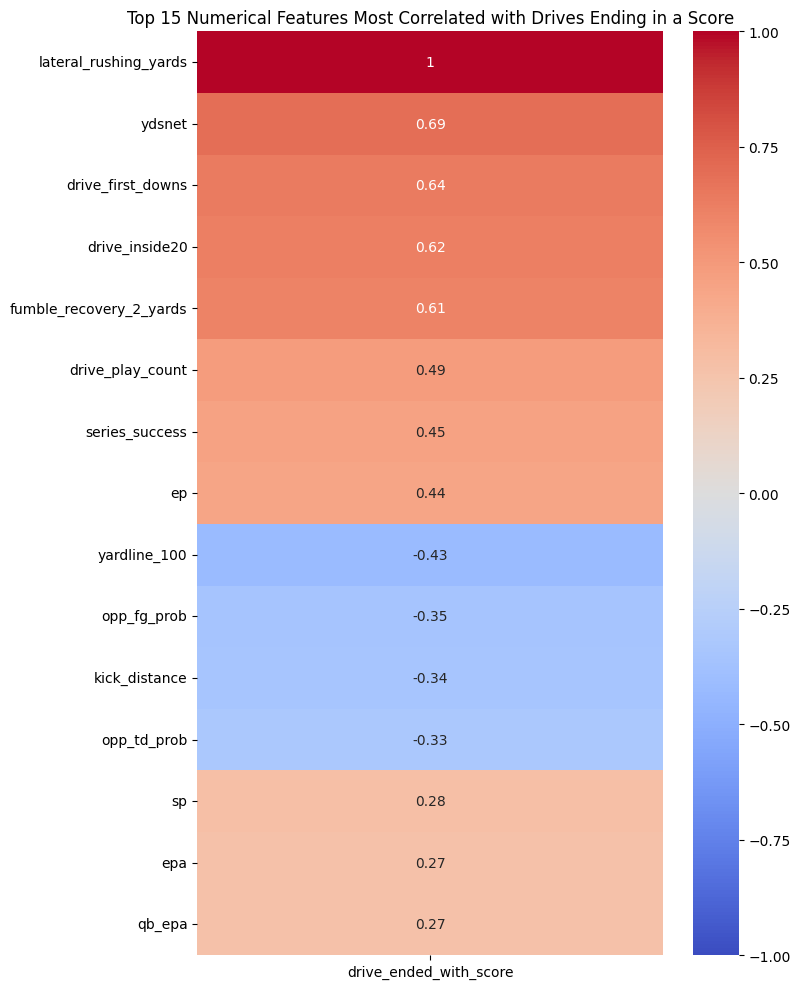

In [ ]:
corr_matrix = df[numerical_features].corr()

top_corr_features = corr_matrix['drive_ended_with_score'].drop('drive_ended_with_score').abs().sort_values(ascending=False).head(15).index.tolist()
print("Top 15 features most correlated with 'drive_ended_with_score':")
print(top_corr_features)

# Plot the heatmap for the features
plt.figure(figsize=(8, 10))
sns.heatmap(corr_matrix.loc[top_corr_features, ['drive_ended_with_score']], annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top 15 Numerical Features Most Correlated with Drives Ending in a Score')
plt.tight_layout()
plt.show()

Looking above, we see what appears to be some of the most important numerical statistics for determining whether a team will score on an offensive drive. The correlation graph above reveals that 'ydsnet', 'drive_first_downs', and 'drive_inside20' may be some of the most important features for determining scoring probability. Let's do some further evaluation!

**Feature Engineering and Extraction**

Below, I am creating the following two metrics for each offense and defense:

- **posteam_score_rate_rolling:** This feature shows the rolling average score rate for the offensive team (posteam) based on the last 10 drives; this value describes how effective a team's offense has been at finishing drives with a score on their most recent possessions. High value shows that this offense is firing on all cylinders - sustaining drives and converting opportunities. Using 10 drives was important because this way we can implement their performance against the specific defense they are competing against in the model.

- **defteam_score_rate_rolling:** This feature represents the rolling average score rate allowed by the defensive team (defteam) based on their past 10 drives faced. Lower values would indicate that the defense has consistently prevented scoring (via pressure, stops and/or turnovers) and it acts as a moving average of recent defensive performance.

Rolling metrics are important for modeling because they give information about each drive, and they also show short-term variation across scorable events (as opposed to season averages). These metrics, taken in the most recent games, give a view of the recent form of both the offense and defense. The model is enabled to account for matchups and momentum across the three events (offense, defense, and recent analysis). These recent aspects will be beneficial in predicting possible outcomes at the drive level of scoring.

It is important to note that the rolling windows are structured to mitigate data leakage. Each value in a rolling window is based on prior information — that is, the scores from the earlier drives at the present point in time. None of the future outcomes are used in calculating a rolling average. The dataset reliably informs the trainings data used in predictive modeling, a large factor in preventing overfitting.

Additional features included:

**Drive number (for each team)**

**Cumulative yards gained**

**Play number within that drive**

**Down and distance context**

**Field position and time remaining**

Categorical variables like **play_type** were handled using one-hot encoding.


In [ ]:
df = df.sort_values(by=['game_id', 'drive_play_id_started', 'play_id'])
df['drive_score_label'] = df.groupby(['game_id', 'drive_play_id_started'])['drive_ended_with_score'].transform('first')

/tmp/ipython-input-12-2750305666.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['drive_score_label'] = df.groupby(['game_id', 'drive_play_id_started'])['drive_ended_with_score'].transform('first')


In [ ]:
team_history = defaultdict(lambda: deque(maxlen=10))
defense_history = defaultdict(lambda: deque(maxlen=10))
rolling_offense_rates = []
rolling_defense_rates = []

for _, row in df.iterrows():
    off_team = row['posteam']
    def_team = row['defteam']

    off_hist = team_history[off_team]
    def_hist = defense_history[def_team]

    off_rate = sum(off_hist) / len(off_hist) if off_hist else 0.5
    def_rate = sum(def_hist) / len(def_hist) if def_hist else 0.5

    rolling_offense_rates.append(off_rate)
    rolling_defense_rates.append(def_rate)

    off_hist.append(row['drive_ended_with_score'])
    def_hist.append(row['drive_ended_with_score'])

df['posteam_score_rate_rolling'] = rolling_offense_rates
df['defteam_score_rate_rolling'] = rolling_defense_rates

/tmp/ipython-input-13-3189931881.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['posteam_score_rate_rolling'] = rolling_offense_rates
/tmp/ipython-input-13-3189931881.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['defteam_score_rate_rolling'] = rolling_defense_rates


In [ ]:
df['play_number'] = df.groupby(['game_id', 'drive_play_id_started']).cumcount() + 1
df['yards_gained_cum'] = df.groupby(['game_id', 'drive_play_id_started'])['yards_gained'].cumsum().fillna(0)

/tmp/ipython-input-14-3986774910.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['play_number'] = df.groupby(['game_id', 'drive_play_id_started']).cumcount() + 1
/tmp/ipython-input-14-3986774910.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['yards_gained_cum'] = df.groupby(['game_id', 'drive_play_id_started'])['yards_gained'].cumsum().fillna(0)


In [ ]:
df['drive_number'] = df.groupby(['game_id', 'posteam'])['drive_play_id_started'].transform(
    lambda x: pd.factorize(x)[0] + 1)

/tmp/ipython-input-15-1584679134.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['drive_number'] = df.groupby(['game_id', 'posteam'])['drive_play_id_started'].transform(


**Model Building and Testing**

In order to begin the model building for the project, I will input the key features selected above and create a training and testing dataset. The training set will allow the model to start to learn any patterns and relationships that exist. The testing dataset will then allow for evaluation of the model's performance (unseen data). This is important for ensuring accuracy and minimizing over-fitting.

The features being used were chosen based off the analysis above. The features include:

**'down':**

**'ydstogo':**

**'yardline_100':**

**'quarter_seconds_remaining':**

**'score_differential':**

**'posteam_score_rate_rolling':**

**'defteam_score_rate_rolling':**

**'drive_number':**

**'play_number':**

**'yards_gained_cum':**

**'drive_inside20':**

**'drive_first_downs':**

**'play_type':**

Below, I take all the numeric and encoded categorical features and combines them into one dataset (X) by stacking them next to each other; this is done in the sparse format to minimize memory usage since one-hot encodings create many zeros.

Missing values in the numerical features were handled using median imputation. Missing values in categorical features were filled with the string 'NA' to handle them as a special category before performing one-hot encoding.

In [ ]:
#Select features and target
num_feats = [
    'down', 'ydstogo', 'yardline_100', 'quarter_seconds_remaining',
    'score_differential', 'posteam_score_rate_rolling',
    'defteam_score_rate_rolling', 'drive_number','play_number', 'yards_gained_cum',
    'drive_inside20','drive_first_downs']
cat_feats = ['play_type']

**Plotting of Numeric Distributions Before Running Training/Testing Datasets**

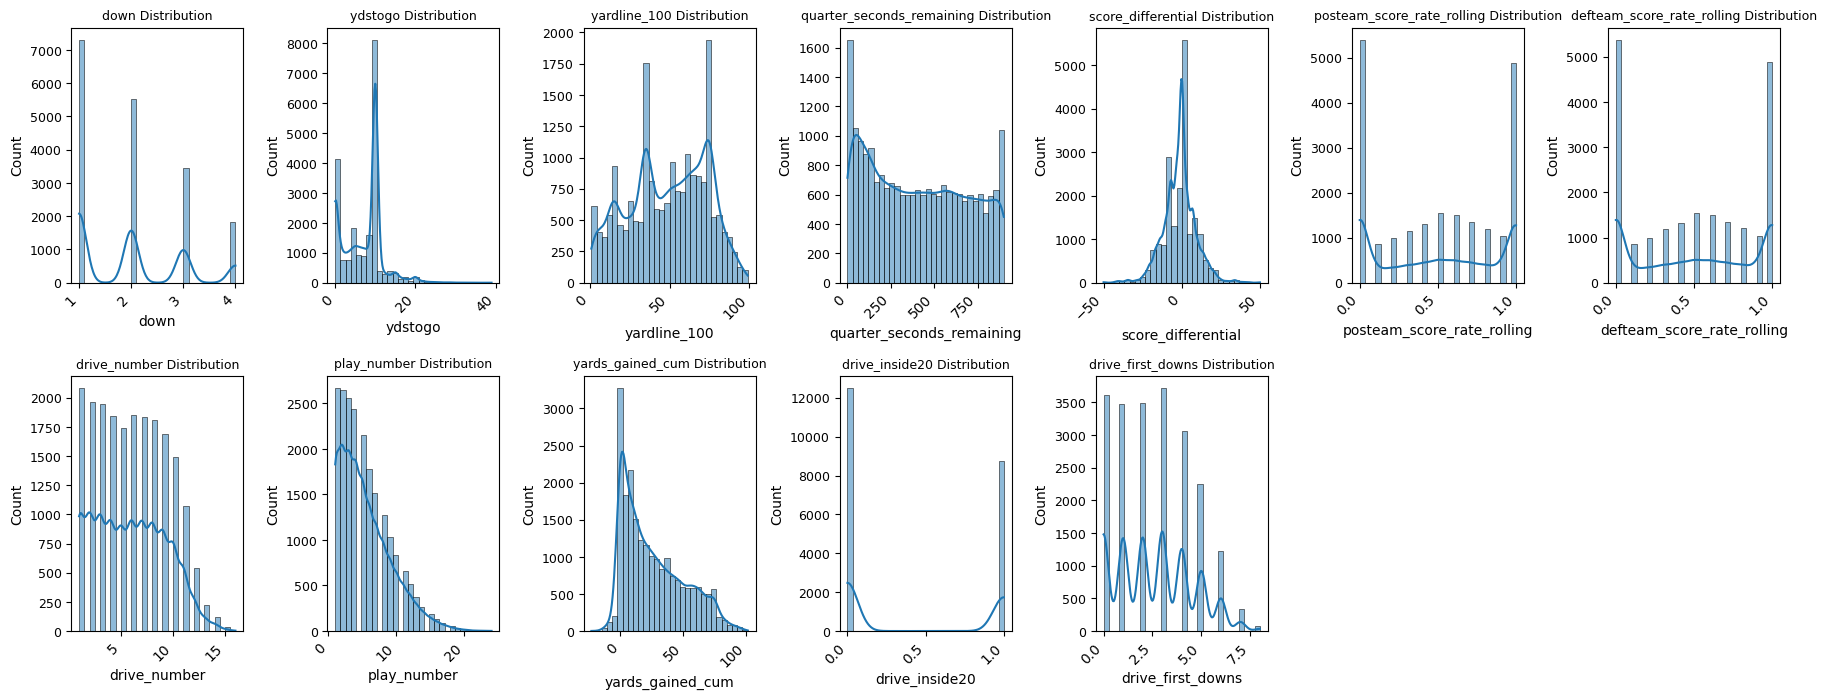

In [ ]:
plt.figure(figsize=(18, 10))
for i, feature in enumerate(num_feats, 1):
    plt.subplot(3, 7, i)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'{feature} Distribution', fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

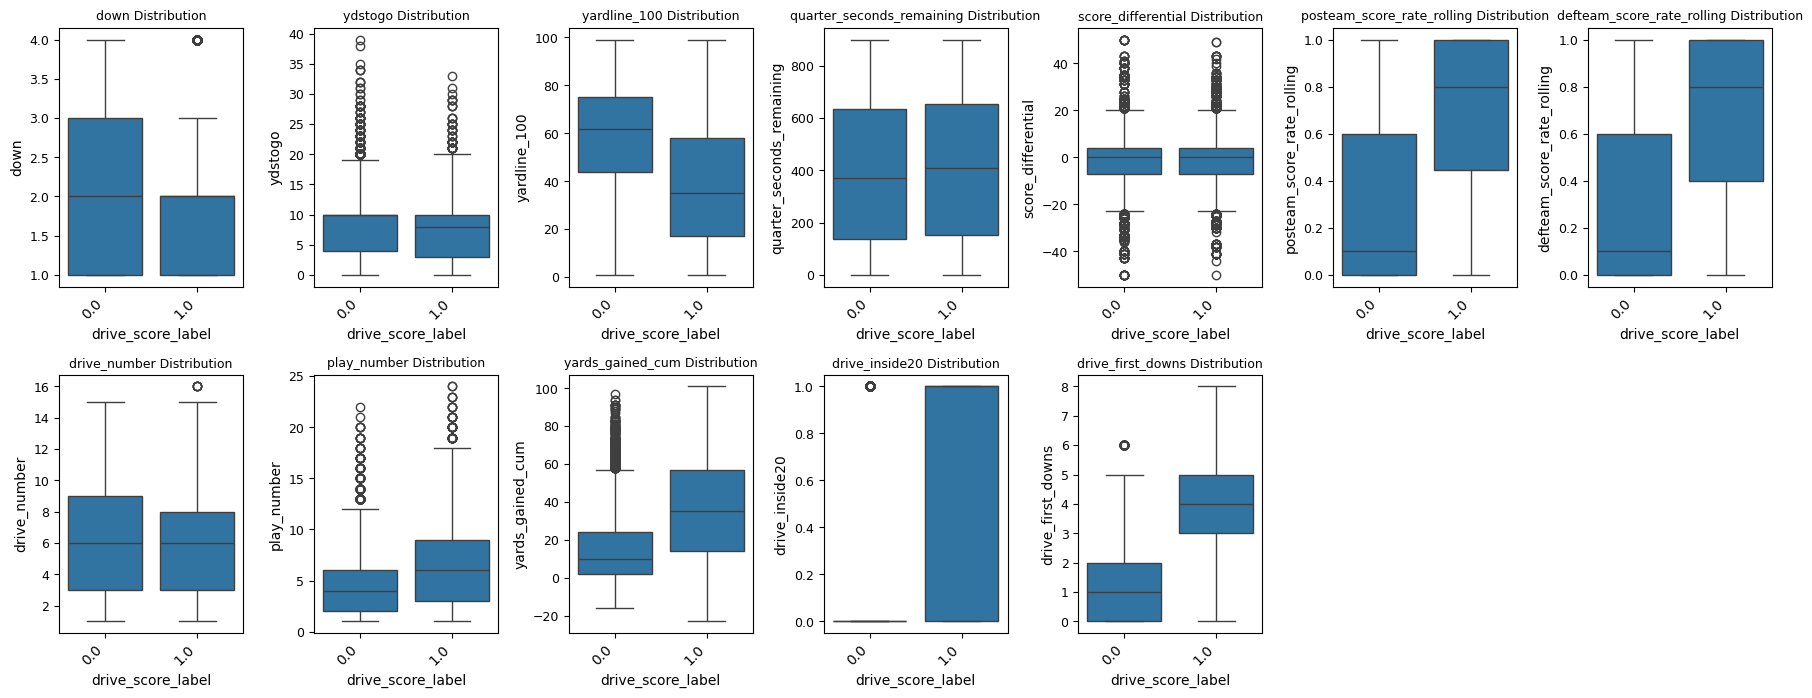

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(18, 10))
for i, feature in enumerate(num_feats, 1):
    plt.subplot(3, 7, i)
    sns.boxplot(data=df, x='drive_score_label', y=feature)
    plt.title(f'{feature} Distribution', fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

The distribution of the numeric variables used are all extremely intriguing as they appear to show some kind of change depending on if the drive resulted in a score or not. Although these differences may appear small, they are extremel critical in determining what features to use in the model.

In [ ]:
X_num = df[num_feats]
X_cat = df[cat_feats].fillna('NA')
y = df['drive_score_label']

#Imputing numeric variables
imputer = SimpleImputer(strategy='median')
X_num_clean = imputer.fit_transform(X_num)

#One-Hot Encoder for categorical variables
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cat_encoded = encoder.fit_transform(X_cat)

#combining categorical and numerical columns
X = sparse.hstack([X_num_clean, X_cat_encoded])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The following models will be tested:

**Logistic Regression** - This model predicts the probability of a binary outcome (whether a drive results in a score) given the input features. It is a interpretable model that relates probabilities, or odds, of the outcome using a logistic function.

**Gradient Boosting** - This ensemble technique typically uses decision trees to build strong predictive models. The decision trees are built in a series in which each subsequent trees corrects the errors of the previous one. The collection of weak models are built into a single accurate model.

**Random Forest** - A Random Forest Model uses the combination of multiple decision trees to make a well-rounded prediction. It uses ensemble learning (combination of models to produce efficient results) to get to a single result and is very flexible.

**Random Forest**

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_rf)
print(f"Random Forest Test AUC: {auc:.3f}")


logloss_rf = log_loss(y_test, y_pred_rf)
print(f"Random Forest Test Log Loss: {logloss_rf:.3f}")

Random Forest Test AUC: 0.986
Random Forest Test Log Loss: 0.155


**Gradient Boosting**

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_gb = gb.predict_proba(X_test)[:, 1]
auc_gb = roc_auc_score(y_test, y_pred_gb)
print(f"Gradient Boosting Test AUC: {auc_gb:.3f}")

logloss_gb = log_loss(y_test, y_pred_gb)
print(f"Gradient Boosting Test Log Loss: {logloss_gb:.3f}")

Gradient Boosting Test AUC: 0.983
Gradient Boosting Test Log Loss: 0.177


**Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500, random_state=42)

In [ ]:
y_pred_lr = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr)
print(f"Logistic Regression Test AUC: {auc_lr:.3f}")

logloss_lr = log_loss(y_test, y_pred_lr)
print(f"Logistic Regression Test Log Loss: {logloss_lr:.3f}")

Logistic Regression Test AUC: 0.944
Logistic Regression Test Log Loss: 0.301


**Evaluation Metrics Explained**

**AUC** - This stands for Area Under the Curve. It is used to assess the performance of a binary classification model (in this case whether the drive ended in a score (1) or not (0)). These values range from 0.5 to 1, with scores closer to 0.5 suggesting that the model is not better than guessing randomly and scores closer to 1.0 suggesting the model can effectively distinguish between the different class (drive ending with a score) labels. If the dataset being used is roughly balanced and the target variable a not a zero-inflated event, this is then a great evaluation tool.

 **Log Loss** - This measures the difference between predicted probabilities and actual values. It is common for binary classification models as well and a lower Log Loss score suggest better model performance. Wrong probability predictions are penalized. The lower the Log Loss, the better the model is!

# **ROC Curve**

The ROC Curve (Receiver Operating Characteristic) is a graph of the True Positive Rate, or sensitivity, against the False Positive Rate. It is extremely important for evaluating the overall performance of each model and comparing the diagnostic accuracy. Moreover, the ROC Curve is not optimal for zero-inflated events because of its sensitivity to class imbalance and of likely over-representation of the true negatives (by predicting the negative class every time, the model could achieve a very good ROC AUC score). In the perfect word, the lines of the ROC Curve would occupy the top left corner, emphasizing a very high true positive rate and low false positive rate.

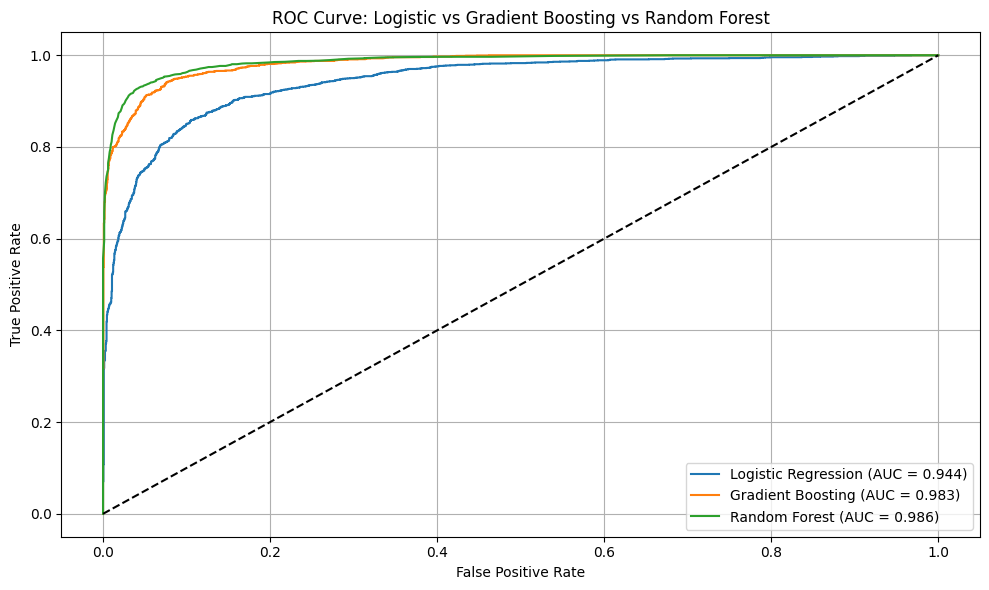

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- ROC Curve Data ---

# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_pred_lr)
lr_auc = auc(lr_fpr, lr_tpr)

# Gradient Boosting
gb_fpr, gb_tpr, _ = roc_curve(y_test, y_pred_gb)
gb_auc = auc(gb_fpr, gb_tpr)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_pred_rf)
rf_auc = auc(rf_fpr, rf_tpr)

# --- Plot ROC Curves ---
plt.figure(figsize=(10, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic vs Gradient Boosting vs Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df['predicted_drive_score_prob'] = rf.predict_proba(X)[:, 1]

/tmp/ipython-input-28-2798823997.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['predicted_drive_score_prob'] = rf.predict_proba(X)[:, 1]


**Random Forest Model Performed the Best**

By looking at the models above and the evaluation metrics, we can see that the Random Forest Model performed the best. It had the highest AUC  and lowest Log Loss. The ROC Curves also show this.

Moreover, the ROC Curves are all hovering in the top left corner - a great sign! This shows a very high true positive rate and low false positive rate for the models.

# **Binning Probabilities**

/tmp/ipython-input-29-425044112.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_predictions_summary = df_predictions.groupby('prob_bin')['actual'].agg(['count', 'mean'])
/tmp/ipython-input-29-425044112.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_predictions_summary['binning_mid_point'] = df_predictions.groupby('prob_bin')['predicted_probability'].mean().values


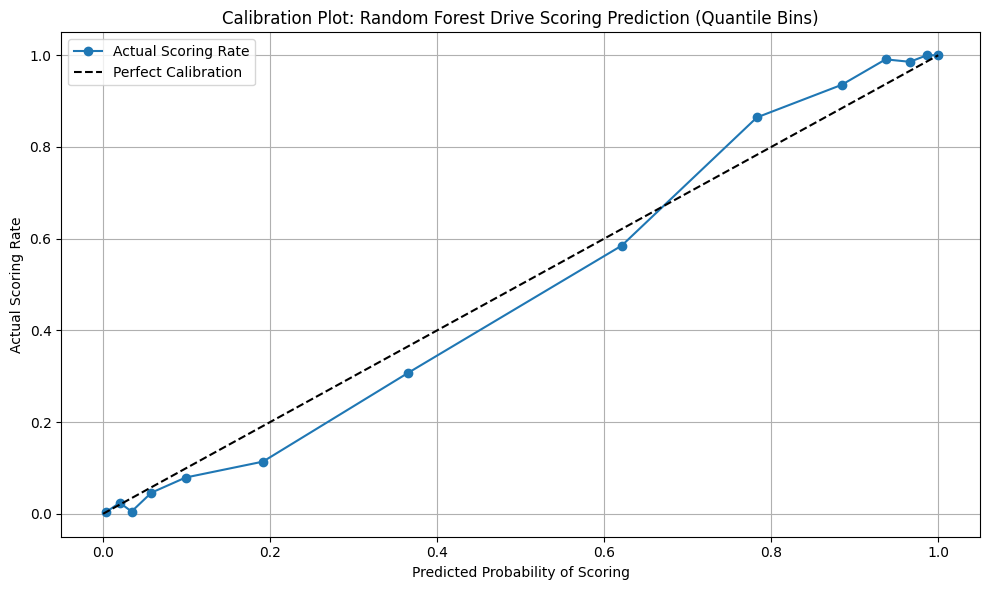

,count,mean,binning_mid_point
prob_bin,,,
"(-0.001, 0.01]",989,0.003033,0.003094
"(0.01, 0.02]",166,0.024096,0.020000
"(0.02, 0.04]",202,0.004950,0.034183
"(0.04, 0.07]",174,0.045977,0.057843
"(0.07, 0.13]",177,0.079096,0.098896
"(0.13, 0.26]",211,0.113744,0.191407
"(0.26, 0.5]",208,0.307692,0.365556
"(0.5, 0.71]",212,0.584906,0.621061
"(0.71, 0.84]",214,0.864486,0.782897


In [ ]:
n_bins = 20

# Create DataFrame of predictions and actuals
df_predictions = pd.DataFrame({
    'predicted_probability': y_pred_rf,
    'actual': y_test.reset_index(drop=True)
})

df_predictions['prob_bin'] = pd.qcut(df_predictions['predicted_probability'], q=n_bins, duplicates='drop')

# Group by bin and summarize
df_predictions_summary = df_predictions.groupby('prob_bin')['actual'].agg(['count', 'mean'])
df_predictions_summary['binning_mid_point'] = df_predictions.groupby('prob_bin')['predicted_probability'].mean().values

# Plot calibration curve
plt.figure(figsize=(10, 6))
plt.plot(df_predictions_summary['binning_mid_point'], df_predictions_summary['mean'], marker='o', label='Actual Scoring Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Predicted Probability of Scoring')
plt.ylabel('Actual Scoring Rate')
plt.title('Calibration Plot: Random Forest Drive Scoring Prediction (Quantile Bins)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
df_predictions_summary

In [ ]:
# Baseline: Predict the average probability for every observation
baseline_prob = y_test.mean()
baseline_log_loss = log_loss(y_test, np.full_like(y_test, baseline_prob, dtype=np.float64))

# Model Log Loss using calibrated Random Forest probabilities
rf_log_loss = log_loss(y_test, y_pred_rf)

# Percent improvement vs. baseline
improvement = (baseline_log_loss - rf_log_loss) / baseline_log_loss * 100

# Print comparison
print(f'Baseline Log Loss                : {baseline_log_loss:.4f}')
print(f'Random Forest Log Loss           : {rf_log_loss:.4f}')
print(f'Improvement in Log Loss (Random Forest): {improvement:.2f}%')

Baseline Log Loss                : 0.6931
Random Forest Log Loss           : 0.1546
Improvement in Log Loss (Random Forest): 77.69%


The quantile-binned calibration table indicates that the Random Forest model provides scoring probability predictions that are very well-calibrated. The predicted probabilities closely track with the actual scoring rate across all probability ranges - especially in the higher confidence areas where the model was very nearly perfectly calibrated.

To assess probabilistic accuracy, we constructed a calibration plot with quantile-based binning. The predicted probabilities tracked closely with the actual scoring rates on a per-bin basis, demonstrating the probabilistic confidence of the model.
We also estimated the log loss relative to a naive baseline:

The estimated probabilities of the Random Forest model closely track true outcomes, especially in high-confidence bins, showing excellent calibration. The calibration plot shows that estimated probabilities are closely followed by observed scoring rates for all bins. Log loss assessment also exhibits the model's superiority with a value of 0.1546 compared to a baseline of 0.6931. This is an improvement of 77.69% over the naive average-probability model. Overall, the model offers reliable and accurate scoring probability estimates.

**Permuation Feature Importance**

Permutation feature importance measures the contribution of each feature to predicting the probability the drive will end in a score. It calculates the variation of the model as its performance changes when the feature is randomly changed. This tells us which inputs (i.e., field position, down, time remaining) are truly informing the model’s decisions versus simply appearing as a coincidence. It is a helpful way to understand complex models while maintaining the integrity of the predictive "output" of the model and simultaneously giving added strategic insight into what things are actually important during a drive.

/tmp/ipython-input-54-4117273356.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


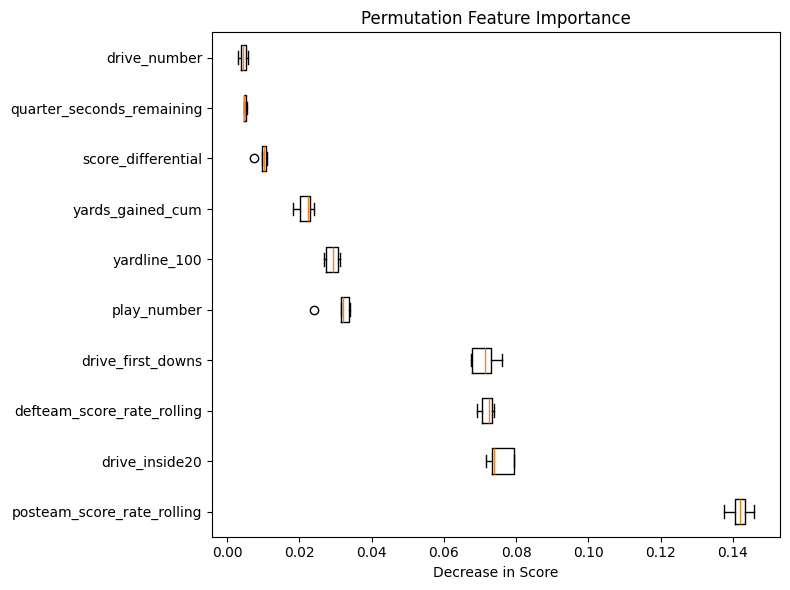

In [ ]:
perm = permutation_importance(rf, X_test.toarray(), y_test, n_repeats=5, random_state=42, n_jobs=-1)
feature_names = num_feats + list(encoder.get_feature_names_out(cat_feats))

top_10_idx = perm.importances_mean.argsort()[-10:][::-1]

plt.figure(figsize=(8, 6))
plt.boxplot(
    perm.importances[top_10_idx].T,
    vert=False,
    labels=np.array(feature_names)[top_10_idx]
)
plt.title('Permutation Feature Importance')
plt.xlabel('Decrease in Score')
plt.tight_layout()
plt.show()

The Permutation Feature Importance plot reveals the importance of **'defteam_score_rate_rolling'**, **'drive_inside20'**, '**posteam_score_rate_rolling'**, and **'drive_first_downs'**. When defteam_score_rate_rolling, posteam_score_rate_rolling, and drive_first_downs were randomized, those were the most dramatic reductions in model performance, indicating these features are the most important to know the likelihood of a drive scoring.

This seems very reasonable because both teams' rolling score rates capture recent momentum and efficiency! Moreover, first down attempts reflect a rolling rate of how effective the drive has been at that moment as well. Together these data points provide valuable signals of offensive rhythm and defensive vulnerability, all pointing to largest importance in the model created here!

**Interaction Mode**

I used an interactive widget with ipywidgets to view scoring probabilities over individual drives with the following steps:

Select a game, team, and drive number

See predicted scoring probability on a per-play basis

Annotations summarizing the scoring outcome and final prediction

In [ ]:
#pip install plotly ipywidgets

In [ ]:
output = Output()

def plot_drive_scoring_prob(game, team, drive_num):
    with output:
        clear_output(wait=True)

        drive_data = df[
            (df['game_id'] == game) &
            (df['posteam'] == team) &
            (df['drive_number'] == drive_num)
        ]

        if drive_data.empty:
            print(f"No data for Game {game}, Team {team}, Drive {drive_num}.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))
        x = drive_data['play_number']
        y = drive_data['predicted_drive_score_prob']

        ax.plot(x, y, marker='o', linestyle='-', linewidth=2, color='navy')

        # Add labels BELOW each data point
        for px, py in zip(x, y):
            ax.annotate(
                f"{py:.2f}",
                xy=(px, py),
                xytext=(0, -10),  # lower the label
                textcoords='offset points',
                ha='center',
                va='top',
                fontsize=9,
                color='black'
            )

        ax.set_title(f"Game: {game}, Driving Team: {team}, Drive Number: {drive_num}", fontsize=14, weight='bold')
        ax.set_xlabel("Play Number", fontsize=12)
        ax.set_ylabel("Probability of Scoring Drive", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(np.arange(x.min(), x.max() + 1, 1))

        # Annotate final result
        end_prob = y.iloc[-1]
        scored = drive_data['drive_ended_with_score'].iloc[-1]
        pts = drive_data['drive_points'].iloc[-1] if 'drive_points' in drive_data else None
        result = "Scored" if scored else "No Score"
        if pts:
            result += f" — {int(pts)} pts"
        annotation = f"{result}\nProb: {end_prob:.2f}"
        annotation_color = 'green' if scored else 'red'

        ax.annotate(
            annotation,
            xy=(x.iloc[-1], end_prob),
            xytext=(10, 10),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', edgecolor=annotation_color, linewidth=1.5),
            arrowprops=dict(arrowstyle='->', lw=1, color=annotation_color),
            fontsize=10,
            color=annotation_color
        )

        plt.tight_layout()
        plt.show()


# Interactive widgets
games = sorted(df['game_id'].dropna().unique())
teams = sorted(df['posteam'].dropna().unique())
max_drive = int(df['drive_number'].max())

interactive_plot = interact_manual(
    plot_drive_scoring_prob,
    game=widgets.Dropdown(options=games, description='Game:'),
    team=widgets.Dropdown(options=teams, description='Team:'),
    drive_num=widgets.IntSlider(min=1, max=max_drive, description='Drive #')
)

display(interactive_plot, output)

interactive(children=(Dropdown(description='Game:', options=('2021_01_ARI_TEN', '2021_01_BAL_LV', '2021_01_CHI…

<function __main__.plot_drive_scoring_prob(game, team, drive_num)>

Output()

# **Next Steps and Conclusion**

Overall, the Random Forest model performed best in predicting the probability of an NFL drive resulting in a score. The Random Forest model also uniquely provided interpretable feature importance that mapped back to action and decision-making. The '**posteam_score_rate_rolling**', '**defteam_score_rate_rolling**', and '**drive_first_downs**' were some of the most influential inputs to the model's predictions. This revealed that each team's recent success on the offensive and defensive end influenced the model's decision making process - this was expected! These features provided dynamic information outside of the play itself and gave context to the complexities of execution and momentum dynamics of a game.

The following variables: **'down'**, **'ydstogo'**, **'yardline_100'**, **'score_differential'**, and **'quarter_seconds_remaining'**, represented the fundamental situational context of each play in that they indicated how the offense faced the tactical constraints and time pressure. These characteristics allowed the model to understand how field position, score, and time influenced the likelihood of scoring. In addition, rolling average scoring rates for offense and defense (**'posteam_score_rate_rolling'** and **'defteam_score_rate_rolling'**) gave insights to recent trend in performance and relative strength of the teams, serving as dynamic momentum indicators. Cumulative drive-level characteristics like **'drive_number'**, **'play_number'**, **'yards_gained_cum'**, and **'drive_first_downs'** gave a snapshot of drive progressiveness and effectiveness, allowing the model to distinguish consistent, effective drives from the ones that stall. The inclusion of play type and whether or not the drive made it inside the red zone (**'drive_inside20'**) further contributed to the model's understanding of situational leverage and ability to predict scoring opportunities. In short, all these characteristics together produced a strongly calibrated model that not only was well-suited to matching actual results all the way along the probability spectrum but actually achieved significantly less log loss than a naive baseline—suggesting the model's ability to make strong, confident scoring probability estimates from contextual information.

In the future, the ability to increase the model's input offers significant opportunity. Incorporating factors such as pre-snap win probability or game script indicators (timeouts or possession state) would add significant contextual value. Additionally, feature engineering can be enhanced by including team-level tendencies (pace, blitz rate, or defensive package set-up) as well as other game variable inputs (injuries, weather and subjectively measured situations such as home-field advantage), which would provide greater accuracy and reflect layered realities of NFL strategy.

Publishing the model and providing an interactive user-friendly interface like an API, website or dashboard will be critical since actionable insight will be required for actual use. Having football coaches, analysts, and betting trusts being able to generate queries to contextualize certain scenarios across ranges of play while using key variables to assess some probability of out-comes on scoring situations would be beneficial. Moving forward, the focus of this project will shift to explainability, applicability, and integration for coaches, analysts, and users to better understand, predict, and continue to evolve the model.